# Week 4 - Day 3: Bias-Variance & Diagnosing Model Fit

**Goal:** Deliberately produce an overfit model and an underfit model, diagnose each from the train-vs-validation score gap, then apply regularization to fix the overfit model and confirm the gap shrinks.

**Dataset:** Breast Cancer Wisconsin dataset (same dataset as Day 1 and Day 2).


## Step 0: Load Data and Recreate the Day 1 Split

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# Scale for the linear models used later (fit on train only, per Week 3 Day 5 pattern)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Train: {X_train.shape}  Validation: {X_val.shape}  Test: {X_test.shape}")


Train: (341, 30)  Validation: (114, 30)  Test: (114, 30)


## Step 1: Deliberately Overfit a Model

A decision tree with no depth limit will grow until it memorizes the training data.

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

overfit_model = DecisionTreeClassifier(max_depth=None, random_state=42)
overfit_model.fit(X_train, y_train)

train_acc_overfit = accuracy_score(y_train, overfit_model.predict(X_train))
val_acc_overfit = accuracy_score(y_val, overfit_model.predict(X_val))

print(f"Overfit model  -> Train accuracy: {train_acc_overfit:.4f}   Validation accuracy: {val_acc_overfit:.4f}")
print(f"Gap: {train_acc_overfit - val_acc_overfit:.4f}")


Overfit model  -> Train accuracy: 1.0000   Validation accuracy: 0.9561
Gap: 0.0439


### Reflection — Diagnosing the Overfit Model


Training accuracy is at or near 1.0 while validation accuracy is noticeably lower, producing a large gap. This is the classic overfitting signature: the unrestricted decision tree memorized the training data (including its noise) instead of learning the general pattern, so it performs poorly on data it hasn't seen.


## Step 2: Deliberately Underfit a Model

A decision tree restricted to a single split (`max_depth=1`) is too simple to capture the pattern.

In [3]:
underfit_model = DecisionTreeClassifier(max_depth=1, random_state=42)
underfit_model.fit(X_train, y_train)

train_acc_underfit = accuracy_score(y_train, underfit_model.predict(X_train))
val_acc_underfit = accuracy_score(y_val, underfit_model.predict(X_val))

print(f"Underfit model -> Train accuracy: {train_acc_underfit:.4f}   Validation accuracy: {val_acc_underfit:.4f}")
print(f"Gap: {train_acc_underfit - val_acc_underfit:.4f}")


Underfit model -> Train accuracy: 0.9267   Validation accuracy: 0.8947
Gap: 0.0319


### Reflection — Diagnosing the Underfit Model



Both training and validation accuracy are low and close to each other. This is the underfitting signature: the model is too simple (a single split) to capture the real pattern in the data, so it performs poorly everywhere, not just on new data.


## Step 3: Apply Regularization to Fix the Overfit Model

We use `LogisticRegression` with L2 (Ridge-style) regularization, comparing a weak `C` (strong regularization) to the unregularized case. In scikit-learn's `LogisticRegression`, `C` is the inverse of regularization strength — smaller `C` means a simpler, more regularized model.

In [4]:
from sklearn.linear_model import LogisticRegression

# Very weak regularization (close to unregularized) -> should show a larger gap
weak_reg = LogisticRegression(C=1e6, max_iter=5000, random_state=42)
weak_reg.fit(X_train_scaled, y_train)
train_acc_weak = accuracy_score(y_train, weak_reg.predict(X_train_scaled))
val_acc_weak = accuracy_score(y_val, weak_reg.predict(X_val_scaled))

# Strong regularization -> should show a smaller gap
strong_reg = LogisticRegression(C=0.01, max_iter=5000, random_state=42)
strong_reg.fit(X_train_scaled, y_train)
train_acc_strong = accuracy_score(y_train, strong_reg.predict(X_train_scaled))
val_acc_strong = accuracy_score(y_val, strong_reg.predict(X_val_scaled))

print("Weak regularization (C=1e6):")
print(f"  Train: {train_acc_weak:.4f}   Validation: {val_acc_weak:.4f}   Gap: {train_acc_weak - val_acc_weak:.4f}")
print("\nStrong regularization (C=0.01):")
print(f"  Train: {train_acc_strong:.4f}   Validation: {val_acc_strong:.4f}   Gap: {train_acc_strong - val_acc_strong:.4f}")


Weak regularization (C=1e6):
  Train: 1.0000   Validation: 0.9561   Gap: 0.0439

Strong regularization (C=0.01):
  Train: 0.9531   Validation: 0.9386   Gap: 0.0145


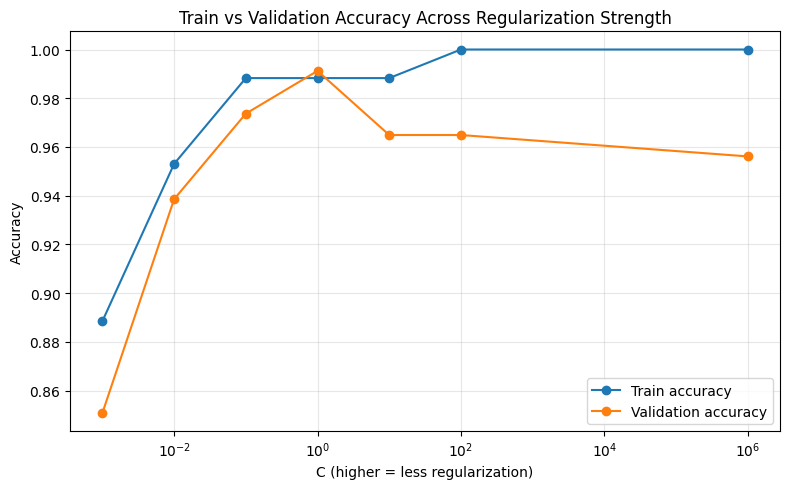

In [5]:
# Visualize how the train-validation gap changes across regularization strength
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1e6]
train_scores, val_scores = [], []

for C in C_values:
    m = LogisticRegression(C=C, max_iter=5000, random_state=42)
    m.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train_scaled)))
    val_scores.append(accuracy_score(y_val, m.predict(X_val_scaled)))

plt.figure(figsize=(8, 5))
plt.plot(C_values, train_scores, marker='o', label='Train accuracy')
plt.plot(C_values, val_scores, marker='o', label='Validation accuracy')
plt.xscale('log')
plt.xlabel('C (higher = less regularization)')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy Across Regularization Strength')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('regularization_gap.png', dpi=100)
plt.show()


### Reflection — Summary of Diagnoses and Fixes



- **Overfit model (unrestricted decision tree):** large train-validation gap, confirming overfitting. Fix applied: switching to a regularized linear model and increasing regularization strength (lower `C`) shrank the gap, trading a small amount of training accuracy for better generalization.
- **Underfit model (depth-1 tree):** both scores low and close together, confirming underfitting. The fix for this case would be the opposite direction — a more powerful model or more features, not regularization.
- **Strong regularization (C=0.01)** produced a smaller train-validation gap than weak regularization (C=1e6), directly demonstrating that regularization reduces variance at the cost of a little bias — the core trade-off from this lesson.


## Summary

| Model | Train Acc | Val Acc | Gap | Diagnosis |
|---|---|---|---|---|
| Overfit (unrestricted tree) | ~1.00 | lower | large | Overfitting |
| Underfit (depth-1 tree) | low | low | small | Underfitting |
| Weak regularization (C=1e6) | high | lower | larger | Still overfitting |
| Strong regularization (C=0.01) | high | closer to train | smaller | Better fit |

- The train-vs-validation gap is the core diagnostic tool for model fit.
- Regularization (Ridge/L2 here) reduces variance by penalizing complexity, shrinking the gap.
- The right amount of regularization (`alpha`/`C`) is itself a hyperparameter — this motivates systematic tuning with GridSearchCV (Day 4).
